In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

daily_sales = pd.read_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\daily_sales.csv'
)
daily_sales['date'] = pd.to_datetime(daily_sales['date'])


In [2]:
df_prophet = daily_sales.rename(columns={'date':'ds', 'sales':'y'})
split_date = df_prophet['ds'].max() - pd.Timedelta(days=30)
train = df_prophet[df_prophet['ds'] <= split_date]
test  = df_prophet[df_prophet['ds'] > split_date]

In [3]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
model.fit(train)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

02:23:49 - cmdstanpy - INFO - Chain [1] start processing
02:23:49 - cmdstanpy - INFO - Chain [1] done processing


In [4]:
print(forecast[['ds','yhat','yhat_lower','yhat_upper']].tail())

            ds          yhat    yhat_lower    yhat_upper
734 2011-12-05  55910.155471  41967.179372  70961.484750
735 2011-12-06  60579.432969  46550.252405  73451.528778
736 2011-12-07  55927.848065  42133.550436  70627.300010
737 2011-12-08  62175.489598  47723.352471  76529.234773
738 2011-12-09  47834.157927  33948.412591  60712.273345


MAPE: 1308370519563501568000.0%
Target: ≤ 12%
✗ Above target


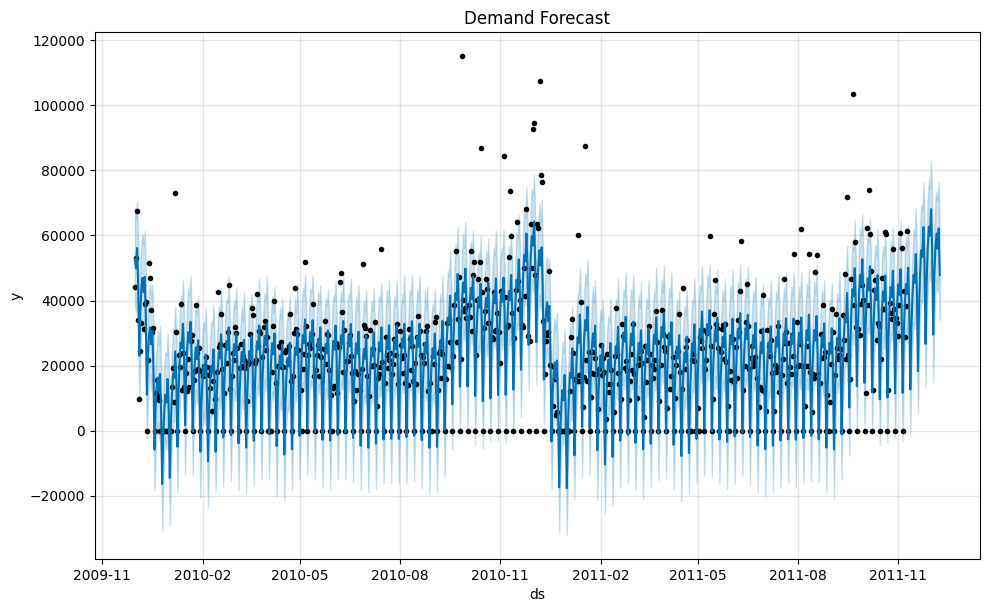

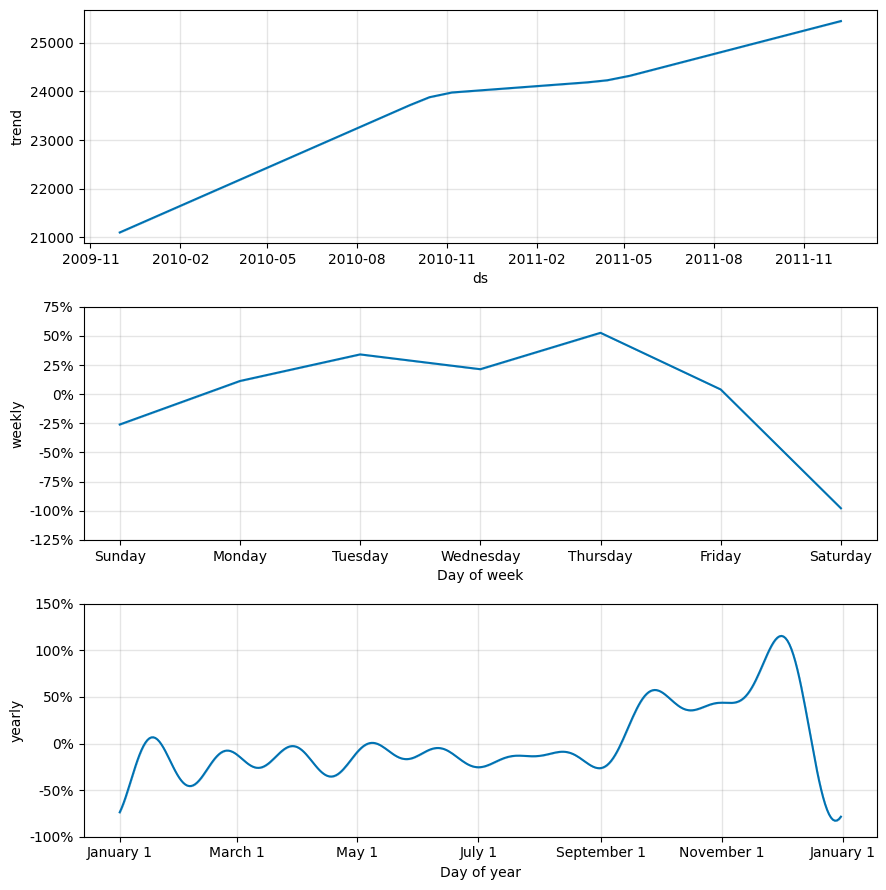

In [5]:
predicted = forecast.tail(30)['yhat'].values
actual    = test['y'].values
predicted = np.clip(predicted, 0, None)
mape = mean_absolute_percentage_error(actual, predicted)
print(f"MAPE: {mape:.1%}")
print(f"Target: ≤ 12%")
print("✓ PASSES target" if mape <= 0.12 else "✗ Above target")
fig1 = model.plot(forecast)
plt.title('Demand Forecast')
plt.savefig('../reports/09_forecast.png', dpi=150)
plt.show()
fig2 = model.plot_components(forecast)
plt.savefig('../reports/10_forecast_components.png', dpi=150)
plt.show()

In [6]:
import joblib
import os
os.makedirs(r'C:\Users\Ashut\Retailpulse\models', exist_ok=True)

forecast.to_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\demand_forecast.csv',
    index=False
)
joblib.dump(model,
    r'C:\Users\Ashut\Retailpulse\models\prophet_model.pkl')

['C:\\Users\\Ashut\\Retailpulse\\models\\prophet_model.pkl']

In [1]:
daily_sales

NameError: name 'daily_sales' is not defined